In [1]:
import numpy as np
import torch
from torchvision import models, transforms
from PIL import Image
import os
import cv2
import matplotlib.pyplot as plt

In [2]:
model = models.densenet121(pretrained=True)
features = model.features
model = torch.nn.Sequential(features,
                            torch.nn.AdaptiveAvgPool2d(output_size=(1, 1)),
                            torch.nn.Flatten()
                            )
model.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
    ])

D:\Mini Project\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Mini Project\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
def apply_clahe(img):
    img_arr = np.array(img.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced_img = clahe.apply(img_arr)
    return Image.fromarray(enhanced_img).convert("RGB")

In [18]:
def extract_features(img_path):
    img = Image.open(img_path).convert("RGB")
    img = apply_clahe(img)
    img = transform(img).unsqueeze(0)

    with torch.no_grad():
        feat = model(img)
    return feat.flatten().cpu().numpy()

Processing: bacteria.jpeg


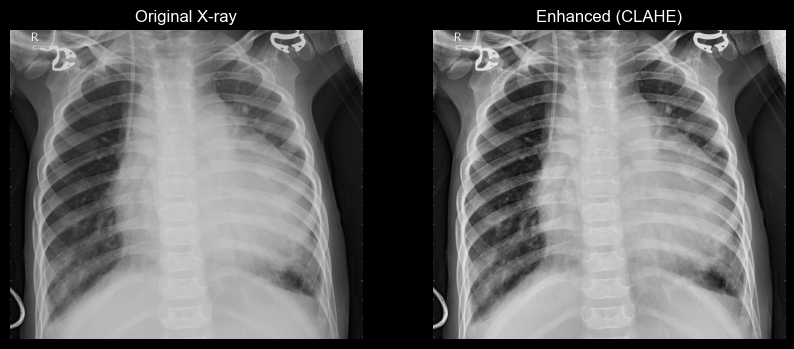

Features extracted. Shape: [-4.4201649e-04  7.6485071e-03 -8.3118206e-04 ...  1.7660127e+00
  4.7570795e-02 -1.3402529e+00]
Processing: normal.jpeg


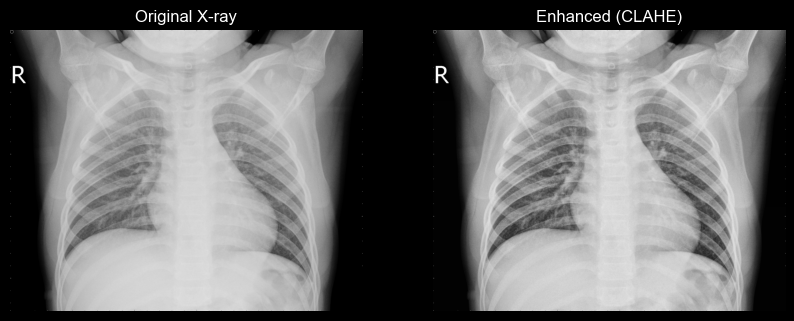

Features extracted. Shape: [-2.0514838e-04  3.2393076e-03  1.9829830e-03 ...  1.6955585e+00
  2.6422727e-01 -1.0914348e+00]
Processing: virus.jpeg


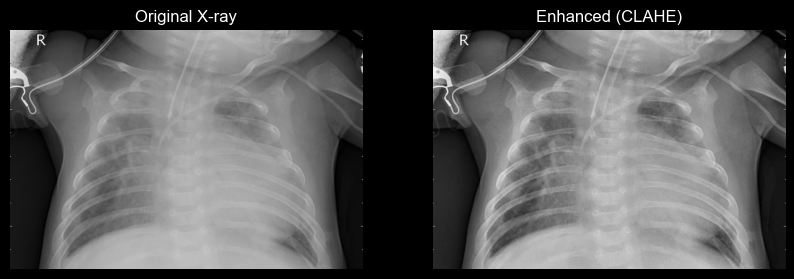

Features extracted. Shape: [-1.6966219e-04  2.5656072e-03  1.8898963e-03 ...  3.4011672e+00
  4.3690342e-02 -5.1757753e-01]


In [16]:
import matplotlib.pyplot as plt

root = 'demo_images/'

if os.path.exists(root):
    for file in os.listdir(root):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            print(f"Processing: {file}")
            raw_img = Image.open(img_path).convert("RGB")
            enhanced_img = apply_clahe(raw_img)

            # 3. Visualization Side-by-Side
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(raw_img)
            ax[0].set_title("Original X-ray")
            ax[0].axis('off')

            ax[1].imshow(enhanced_img)
            ax[1].set_title("Enhanced (CLAHE)")
            ax[1].axis('off')

            plt.show()
            feat = extract_features(img_path)
            print(f"Features extracted. Shape: {feat}")
else:
    print(f"Error: The directory {root} does not exist.")
